# 🏛️ Практическое занятие 3: Точность vs. Прибыль
## Анализ вычислительных ошибок в торговле опционами на NYSE
---

### 🎯 Цели лабораторной работы

По окончании работы вы научитесь:
1. Понимать, как **ошибки усечения чисел с плавающей точкой** распространяются через вычисления греческих коэффициентов опционов.
2. Эмпирически находить **оптимальный шаг конечных разностей**, балансирующий ошибку округления и ошибку усечения.
3. Тестировать производительность **QuantLib и py_vollib** для торговли, чувствительной к задержкам.
4. Реализовывать **стратегию волатильного арбитража**, используя спред «бид-аск» как меру погрешности измерения.
5. Количественно оценивать **потери от дискретизации** — стоимость торговли каждые 5 секунд вместо непрерывной.

---

### ⚠️ Настройка среды

Запустите ячейку ниже **один раз** перед началом работы. Если установка пакета завершится ошибкой — сообщите преподавателю.

In [1]:
# ─────────────────────────────────────────────
# НАСТРОЙКА СРЕДЫ  (Предоставлено — не изменять)
# ─────────────────────────────────────────────
import subprocess, sys

PACKAGES = [
    'numpy', 'scipy', 'matplotlib', 'pandas',
    'QuantLib', 'py_vollib', 'tabulate'
]

for pkg in PACKAGES:
    try:
        __import__(pkg.replace('-', '_').lower())
        print(f'  ✓ {pkg}')
    except ImportError:
        print(f'  ↓ Установка {pkg}...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])
        print(f'  ✓ {pkg} установлен')

print('\n✅ Все пакеты готовы.')

  ↓ Установка numpy...
  ✓ numpy установлен
  ↓ Установка scipy...
  ✓ scipy установлен
  ↓ Установка matplotlib...
  ✓ matplotlib установлен
  ↓ Установка pandas...
  ✓ pandas установлен
  ↓ Установка QuantLib...
  ✓ QuantLib установлен
  ↓ Установка py_vollib...
  ✓ py_vollib установлен
  ↓ Установка tabulate...
  ✓ tabulate установлен

✅ Все пакеты готовы.


In [2]:
# ─────────────────────────────────────────────
# СТАНДАРТНЫЕ ИМПОРТЫ  (Предоставлено — не изменять)
# ─────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy.stats import norm
from scipy.optimize import brentq
from tabulate import tabulate
import time, math, warnings
warnings.filterwarnings('ignore')

# QuantLib
import QuantLib as ql

# py_vollib — лёгкие аналитические греки Блэка–Шоулза
from py_vollib.black_scholes import black_scholes as bs_price
from py_vollib.black_scholes.greeks.analytical import delta as bs_delta_analytical

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11
})

print('✅ Импорт выполнен успешно.')

✅ Импорт выполнен успешно.


---
## 📐 Теоретическое введение: Блэк–Шоулз и греческие коэффициенты

**Цена Блэка–Шоулза** европейского колл-опциона равна:

$$C(S, K, T, r, \sigma) = S \cdot N(d_1) - K e^{-rT} N(d_2)$$

где:
$$d_1 = \frac{\ln(S/K) + (r + \sigma^2/2)T}{\sigma\sqrt{T}}, \qquad d_2 = d_1 - \sigma\sqrt{T}$$

**Греческие коэффициенты** измеряют чувствительность цены опциона $V$ к рыночным параметрам:

| Коэффициент | Формула | Интерпретация |
|-------------|---------|---------------|
| Дельта | $\Delta = \frac{\partial V}{\partial S}$ | Чувствительность цены к базовому активу |
| Гамма | $\Gamma = \frac{\partial^2 V}{\partial S^2}$ | Скорость изменения дельты |
| Тета | $\Theta = \frac{\partial V}{\partial t}$ | Временной распад |
| Вега | $\mathcal{V} = \frac{\partial V}{\partial \sigma}$ | Чувствительность к волатильности |

### 🤔 Почему численная ошибка важна?

На практике вычислять эти производные аналитически часто невозможно (например, при сложных выплатах или американских опционах). Мы приближаем их **численно**. Каждое приближение вносит ошибку — а в торговле опционами ошибка 0,001 в дельте на позиции из 10 000 контрактов оборачивается **реальными денежными потерями**.

**Разложение в ряд Тейлора** для возмущения функции даёт:
$$f(x+h) = f(x) + h f'(x) + \frac{h^2}{2}f''(x) + \frac{h^3}{6}f'''(x) + \cdots$$

**Вопрос для обсуждения:** Используя это разложение, обоснуйте, почему формула центральных разностей даёт ошибку усечения порядка $O(h^2)$, тогда как формула прямых разностей — только $O(h)$. Что это означает для точности хеджирования при большом $h$?

---
## 🔧 Общие рыночные параметры

Эти параметры представляют **гипотетический акционерный опцион, котируемый на NYSE** (например, SPY). Они используются на протяжении всей лабораторной работы.

In [3]:
# ─────────────────────────────────────────────
# ОБЩИЕ РЫНОЧНЫЕ ПАРАМЕТРЫ  (Предоставлено)
# ─────────────────────────────────────────────

S   = 450.00   # Текущая цена базового актива (напр. SPY)
K   = 455.00   # Цена исполнения (страйк)
T   = 30/365   # Время до экспирации: 30 календарных дней
r   = 0.0525   # Безрисковая ставка (прибл. ставка ФРС)
sigma = 0.18   # Подразумеваемая волатильность (18%)
q   = 0.013    # Непрерывная дивидендная доходность
flag = 'c'     # 'c' = колл-опцион

# Аналитическая цена Блэка–Шоулза (эталон)
def bs_call_price(S, K, T, r, sigma, q=0.0):
    """Аналитическая цена колл-опциона по модели Блэка–Шоулза."""
    d1 = (np.log(S / K) + (r - q + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return S * np.exp(-q * T) * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)

V_ref = bs_call_price(S, K, T, r, sigma, q)
print(f'Эталонная цена колл-опциона : ${V_ref:.4f}')
print(f'Параметры                   : S={S}, K={K}, T={T:.4f}лет, r={r}, σ={sigma}, q={q}')

Эталонная цена колл-опциона : $7.6348
Параметры                   : S=450.0, K=455.0, T=0.0822лет, r=0.0525, σ=0.18, q=0.013


---
## 📋 Задание A — Конечные разности: поиск «золотой середины»

### Теоретический контекст

**Формула центральных разностей** аппроксимирует первую производную:

$$\Delta \approx f'(S) \approx \frac{V(S+h) - V(S-h)}{2h}$$

А **гамма** (вторая производная) вычисляется как:

$$\Gamma \approx \frac{V(S+h) - 2V(S) + V(S-h)}{h^2}$$

Между двумя типами ошибок существует фундаментальное **противоречие**:

| Тип ошибки | Причина | Поведение при $h \to 0$ | Поведение при $h \to \infty$ |
|---|---|---|---|
| **Ошибка усечения** | Отбрасывание старших членов ряда Тейлора | Возрастает | Убывает |
| **Ошибка округления** | Взаимная отмена при вычитании чисел с плавающей точкой | Убывает | Возрастает |

**«Золотая середина»** — это значение $h$, при котором *суммарная* ошибка минимальна:
$$h^* \approx \left(\frac{\epsilon_{machine}}{|f'''(x)|}\right)^{1/3} \quad \text{для центральных разностей}$$

где $\epsilon_{machine} \approx 2{,}2 \times 10^{-16}$ для 64-битных чисел с плавающей точкой.

**Вопросы для обсуждения (ответьте в ячейке Markdown ниже):**
1. Почему ошибка округления *возрастает* при уменьшении $h$?
2. При хеджировании большой гамма-позиции какой тип ошибки опаснее на практике?
3. Каково теоретически оптимальное $h$ для дельты при наших параметрах?

### ✏️ Ваши ответы на вопросы для обсуждения (двойной щелчок для редактирования)

**В1 — Почему ошибка округления возрастает при $h \to 0$:**  
*При маленьких h величины V(S+h) и V(S-h) становятся почти равными. При V(S+h)-V(S-h) происходит потеря значащих чисел. Эта малая разница при делении на очень маленькое h приводит к резкому росту ошибки округления*

**В2 — Какая ошибка опаснее для больших гамма-позиций:**  
*При большой гамма-позиции ошибка округления опаснее, так как формула содержит деление на h^2, что усиливает численные погрешности*

**В3 — Теоретически оптимальное $h$ для дельты:**  
*e_machine^(1/3) = 6 * 10^(-6). h\*=6*10^(-6) * (f```(x))^(1/3)*

In [5]:
# ─────────────────────────────────────────────
# ЗАДАНИЕ A — Греческие коэффициенты методом конечных разностей
# ─────────────────────────────────────────────

def compute_delta_central(S, K, T, r, sigma, q, h):
    """
    Вычислить дельту методом центральных разностей.

    Параметры
    ---------
    S, K, T, r, sigma, q : float — стандартные параметры модели БШМ
    h : float — шаг конечных разностей (возмущение S)

    Возвращает
    ----------
    delta : float
    """
    # TODO: Реализация студентом
    # Шаг 1: Вычислить V(S + h) с помощью bs_call_price()
    # Шаг 2: Вычислить V(S - h) с помощью bs_call_price()
    # Шаг 3: Применить формулу центральных разностей
    # ПОДСКАЗКА: delta = (V_up - V_down) / (2 * h)
    
    V_up = bs_call_price(S+h, K, T, r, sigma, q)
    V_down = bs_call_price(S-h, K, T, r, sigma, q)
    delta = (V_up - V_down) / (2 * h)
    
    return delta


def compute_gamma_central(S, K, T, r, sigma, q, h):
    """
    Вычислить гамму методом центральных разностей.

    Возвращает
    ----------
    gamma : float
    """
    # TODO: Реализация студентом
    
    # Шаг 1: Вычислить V(S + h), V(S), V(S - h)
    # Шаг 2: Применить: gamma = (V_up - 2*V_mid + V_down) / h^2
    
    V_up = bs_call_price(S+h, K, T, r, sigma, q)
    V_mid = bs_call_price(S, K, T, r, sigma, q)
    V_down = bs_call_price(S-h, K, T, r, sigma, q)
    
    gamma = (V_up - 2*V_mid + V_down) / h**2
    return gamma


# ── Аналитические эталонные значения (предоставлено) ───────────────────────
d1_ref = (np.log(S/K) + (r - q + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
delta_analytical = np.exp(-q*T) * norm.cdf(d1_ref)
gamma_analytical = np.exp(-q*T) * norm.pdf(d1_ref) / (S * sigma * np.sqrt(T))
print(f'Аналитическая дельта : {delta_analytical:.8f}')
print(f'Аналитическая гамма  : {gamma_analytical:.8f}')

Аналитическая дельта : 0.44961846
Аналитическая гамма  : 0.01702674


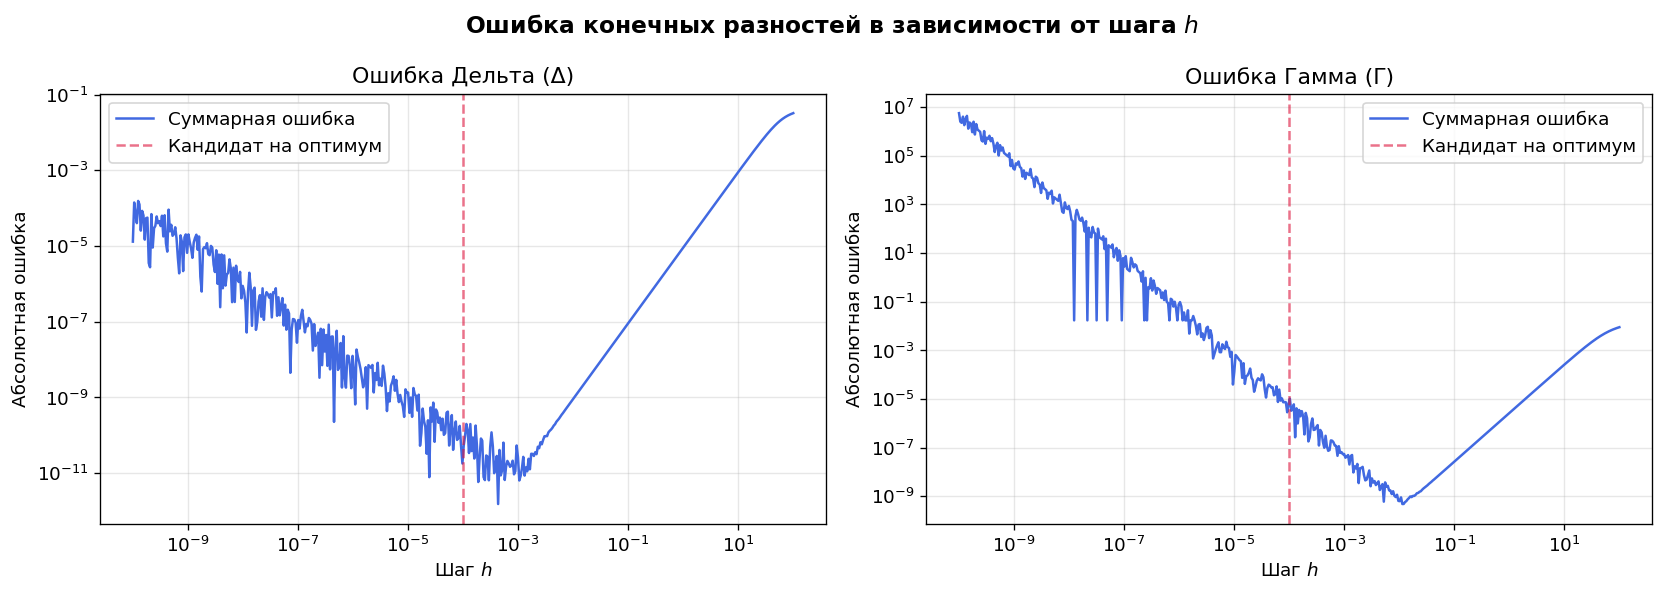


Оптимальный h для дельты : 0.0004337850187558984
Оптимальный h для гаммы  : 0.011379212939153139


In [7]:
# ─────────────────────────────────────────────
# ЗАДАНИЕ A — Перебор шагов и анализ «золотой середины»
# ─────────────────────────────────────────────

# Предоставлено: значения h, охватывающие 12 порядков величины
h_values = np.logspace(-10, 2, 500)

delta_errors = []
gamma_errors = []

for h in h_values:
    # TODO: Реализация студентом
    # 1. Вызвать compute_delta_central() с текущим h
    # 2. Вычислить абсолютную ошибку относительно delta_analytical
    # 3. Повторить для гаммы
    # 4. Добавить ошибки в списки delta_errors и gamma_errors
    
    delta_num = compute_delta_central(S, K, T, r, sigma, q, h)
    delta_err = abs(delta_num - delta_analytical)
    
    gamma_num = compute_gamma_central(S, K, T, r, sigma, q, h)
    gamma_err = abs(gamma_num - gamma_analytical)
    
    delta_errors.append(delta_err)   # заменить None на ваши вычисления
    gamma_errors.append(gamma_err)   # заменить None на ваши вычисления

# ── Построение графиков (предоставлен каркас) ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Ошибка конечных разностей в зависимости от шага $h$', fontsize=14, fontweight='bold')

for ax, errors, greek in zip(axes, [delta_errors, gamma_errors], ['Дельта (Δ)', 'Гамма (Γ)']):
    ax.loglog(h_values, errors, color='royalblue', linewidth=1.5, label='Суммарная ошибка')
    ax.set_xlabel('Шаг $h$')
    ax.set_ylabel('Абсолютная ошибка')
    ax.set_title(f'Ошибка {greek}')
    ax.axvline(x=1e-4, color='crimson', linestyle='--', alpha=0.6, label='Кандидат на оптимум')
    ax.legend()

plt.tight_layout()
plt.show()

# TODO: Реализация студентом
# После построения графика определите значения h, при которых ошибка минимальна.
# Запишите их ниже:


print()
print("=" * 50)
# h_sweet_delta = ?   # Заменить найденным значением
# h_sweet_gamma = ?   # Заменить найденным значением
h_sweet_delta = h_values[np.argmin(delta_errors)]
h_sweet_gamma = h_values[np.argmin(gamma_errors)]
print(f'Оптимальный h для дельты : {h_sweet_delta}')
print(f'Оптимальный h для гаммы  : {h_sweet_gamma}')

In [13]:
# ─────────────────────────────────────────────
# ЗАДАНИЕ A — Три кандидата на h (сводная таблица)
# ─────────────────────────────────────────────

# TODO: Реализация студентом
# Выберите три значения h:
#   h_too_small : настолько малое, что доминирует ошибка округления
#   h_sweet     : найденное вами оптимальное значение
#   h_too_large : настолько большое, что доминирует ошибка усечения

h_too_small = 0.0000000001
h_sweet     = h_sweet_delta
h_too_large = 0.1

candidate_hs = [h_too_small, h_sweet, h_too_large]
labels = ['Слишком малое (доминирует округление)', 'Оптимум', 'Слишком большое (доминирует усечение)']

rows = []
for label, h in zip(labels, candidate_hs):
    d = compute_delta_central(S, K, T, r, sigma, q, h)
    g = compute_gamma_central(S, K, T, r, sigma, q, h)
    d_err = abs(d - delta_analytical)
    g_err = abs(g - gamma_analytical)
    rows.append([label, f'{h:.2e}', f'{d:.8f}', f'{d_err:.2e}', f'{g:.8f}', f'{g_err:.2e}'])

headers = ['Режим', 'h', 'Дельта', 'Ошибка Δ', 'Гамма', 'Ошибка Γ']
print(tabulate(rows, headers=headers, tablefmt='github'))

| Режим                                 |        h |   Дельта |   Ошибка Δ |        Гамма |   Ошибка Γ |
|---------------------------------------|----------|----------|------------|--------------|------------|
| Слишком малое (доминирует округление) | 1e-10    | 0.449631 |   1.3e-05  | -5.68434e+06 |   5.68e+06 |
| Оптимум                               | 0.000434 | 0.449618 |   1.52e-12 |  0.0170266   |   9.79e-08 |
| Слишком большое (доминирует усечение) | 0.1      | 0.449619 |   9.02e-08 |  0.0170267   |   2.63e-08 |


---
## 📋 Задание B — Бенчмаркинг библиотек: скорость против точности

### Теоретический контекст

При **высокочастотной торговле (HFT)** данные опционного рынка на NYSE ARCA поступают каждые **5 секунд**. Преимущество стратегии зависит не только от *точности* вычисления греков, но и от *задержки*: если ваш расчёт дельты занимает 50 мс, а у конкурента — 5 мс, вы проиграете сделку.

Две популярные библиотеки Python для греческих коэффициентов опционов:

| Библиотека | Подход | Преимущества | Недостатки |
|---|---|---|---|
| **QuantLib** | Полный движок ценообразования (бэкенд на C++) | Работает со сложными деривативами и американскими опционами | Высокие накладные расходы на вызов |
| **py_vollib** | Прямые аналитические формулы | Очень быстрый для европейских опционов | Ограничен моделями БШМ |

**Вопрос:** Для стратегии, которой нужно пересчитывать греки каждые 5 секунд для 50 опционов одновременно, какая библиотека предпочтительнее?

### 📊 Что нужно представить
- Реальное время на один расчёт грека (используйте `%timeit`)
- Абсолютное расхождение значений дельты между двумя библиотеками
- Ваша рекомендация с **математическим обоснованием** (не просто «она быстрее»)

**Вопрос для обсуждения:** Если QuantLib использует численное интегрирование внутри (например, для американских опционов), а py_vollib — замкнутую формулу, в чём причина численного расхождения их результатов?

In [14]:
# ─────────────────────────────────────────────
# ЗАДАНИЕ B — Настройка QuantLib  (Предоставлен каркас)
# ─────────────────────────────────────────────

def build_quantlib_option(S, K, T, r, sigma, q, flag='c'):
    """
    Создать объект европейского опциона в QuantLib.
    Возвращает (option, bsm_process), готовый к ценообразованию.
    """
    today    = ql.Date.todaysDate()
    maturity = today + int(T * 365)
    ql.Settings.instance().evaluationDate = today

    option_type = ql.Option.Call if flag == 'c' else ql.Option.Put
    payoff      = ql.PlainVanillaPayoff(option_type, K)
    exercise    = ql.EuropeanExercise(maturity)
    option      = ql.VanillaOption(payoff, exercise)

    spot_handle   = ql.QuoteHandle(ql.SimpleQuote(S))
    flat_ts       = ql.YieldTermStructureHandle(ql.FlatForward(today, r, ql.Actual365Fixed()))
    div_ts        = ql.YieldTermStructureHandle(ql.FlatForward(today, q, ql.Actual365Fixed()))
    vol_ts        = ql.BlackVolTermStructureHandle(ql.BlackConstantVol(today, ql.NullCalendar(), sigma, ql.Actual365Fixed()))
    bsm_process   = ql.BlackScholesMertonProcess(spot_handle, div_ts, flat_ts, vol_ts)

    engine = ql.AnalyticEuropeanEngine(bsm_process)
    option.setPricingEngine(engine)
    return option, bsm_process

# Создать один раз для проверки
ql_option, ql_process = build_quantlib_option(S, K, T, r, sigma, q)
print(f'QuantLib Дельта  : {ql_option.delta():.8f}')
print(f'QuantLib Гамма   : {ql_option.gamma():.8f}')
print(f'QuantLib Цена    : {ql_option.NPV():.4f}')

QuantLib Дельта  : 0.44961846
QuantLib Гамма   : 0.01702674
QuantLib Цена    : 7.6348


In [15]:
# ─────────────────────────────────────────────
# ЗАДАНИЕ B — Эталон py_vollib  (Предоставлен каркас)
# ─────────────────────────────────────────────

# Аналитическая дельта py_vollib (сигнатура: (flag, S, K, t, r, sigma))
pvl_delta = bs_delta_analytical(flag, S, K, T, r, sigma)
pvl_price = bs_price(flag, S, K, T, r, sigma)

print(f'py_vollib Дельта   : {pvl_delta:.8f}')
print(f'py_vollib Цена     : {pvl_price:.4f}')
print(f'Аналит. Дельта     : {delta_analytical:.8f}')
print(f'ΔДельта (QL vs PVL): {abs(ql_option.delta() - pvl_delta):.2e}')

py_vollib Дельта   : 0.45830477
py_vollib Цена     : 7.8531
Аналит. Дельта     : 0.44961846
ΔДельта (QL vs PVL): 8.69e-03


In [23]:
# ─────────────────────────────────────────────
# ЗАДАНИЕ B — Бенчмарк задержки
# ─────────────────────────────────────────────
import timeit

# TODO: Реализация студентом
# Используйте магию %%timeit или модуль timeit для замера:
#   (a) QuantLib: build_quantlib_option(...).delta()
#   (b) py_vollib: bs_delta_analytical(...)
# Запишите результаты ниже.

#
# ПОДСКАЗКА: Для QuantLib замеряйте ПОЛНОЕ построение опциона + вызов .delta()
# (это имитирует переоценку с нуля на каждом тике — что реалистично)
#
# %timeit build_quantlib_option(S, K, T, r, sigma, q)[0].delta()    

delta_time1 = timeit.timeit(lambda: build_quantlib_option(S, K, T, r, sigma, q, flag)[0].delta(), number=1000) / 1000
print(f'Бенчмарк расчёта дельты в QuantLib: {delta_time1}')
delta_time2 = timeit.timeit(lambda: bs_delta_analytical(flag, S, K, T, r, sigma), number=1000) / 1000
print(f'\nБенчмарк расчёта дельты в py_vollib: {delta_time2}')
# %timeit bs_delta_analytical(flag, S, K, T, r, sigma)

Бенчмарк расчёта дельты в QuantLib: 0.00010362689499925182

Бенчмарк расчёта дельты в py_vollib: 1.8407580000712187e-06


In [26]:
# ─────────────────────────────────────────────
# ЗАДАНИЕ B — Симуляция портфеля: 50 опционов × 5-секундный тик
# ─────────────────────────────────────────────

# Предоставлено: генерировать вселенную из 50 опционов
np.random.seed(42)
n_options = 50
strikes   = np.linspace(430, 475, n_options)
expiries  = np.random.uniform(7/365, 60/365, n_options)
ivols     = np.random.uniform(0.14, 0.25, n_options)

print(f'Вселенная опционов: {n_options} коллов, страйки {strikes[0]:.0f}–{strikes[-1]:.0f}')

# TODO: Реализация студентом
# Задача: измерить суммарное время вычисления ВСЕХ 50 дельт каждой библиотекой.
# Это имитирует один полный тик пересчёта.
#
# СТРУКТУРА:
#
t0 = time.perf_counter()
ql_deltas1 = []
for K_i, T_i, sig_i in zip(strikes, expiries, ivols):
    opt, _ = build_quantlib_option(S, K_i, T_i, r, sig_i, q)
    ql_deltas1.append(opt.delta())
ql_time1 = time.perf_counter() - t0
#
# Повторить для py_vollib
#
t0 = time.perf_counter()
ql_deltas2 = []
for K_i, T_i, sig_i in zip(strikes, expiries, ivols):
    delta_val = bs_delta_analytical(flag, S, K_i, T_i, r, sig_i)
    ql_deltas2.append(delta_val)
ql_time2 = time.perf_counter() - t0
# Вывести сравнение: общее время QL vs PVL
# Какое из них укладывается в 5-секундное окно? ОБЕ

print(f'\nВремя 1 - {ql_time1}, Время 2 - {ql_time2}')

Вселенная опционов: 50 коллов, страйки 430–475

Время 1 - 0.012236321999807842, Время 2 - 0.0003904569994119811


### ✏️ Задание B — Ваша рекомендация (двойной щелчок для редактирования)

**Рекомендуемая библиотека для греков в HFT с 5-секундным окном:**  
*py_vollib, так как работает сильно быстрее (примерно в 31 раз)*

**Причина численного расхождения между библиотеками:**  
*QuantLib делает больше внутренних расчётов, а py_vollib использует готовую формулу. Из-за этого появляются небольшие отличия из-за округления*

**При каких условиях вы бы выбрали QuantLib несмотря на задержку?**  
*Если нужно работать с американскими опционами и сложными директивами*

---
## 🏗️ Симулятор рынка

Класс `MarketSimulator` ниже предоставляет **готовый** синтетический поток данных NYSE и API исполнения сделок. Он моделирует структуру 5-секундных тиков опционного рынка NYSE ARCA.

### Справочник по API

| Метод | Описание |
|--------|----------|
| `sim.get_tick()` | Возвращает текущий рыночный снимок в виде словаря |
| `sim.buy(qty)` | Выставить ордер на покупку `qty` контрактов |
| `sim.sell(qty)` | Выставить ордер на продажу `qty` контрактов |
| `sim.pass_()` | Пропустить текущий тик (без торговли) |
| `sim.get_pnl()` | Вернуть текущий реализованный + нереализованный P&L |
| `sim.get_history()` | Вернуть DataFrame всех тиков и сделок |

### Схема данных тика

```python
{
  'time'       : float,   # секунды с начала сессии
  'S'          : float,   # средняя цена базового актива
  'bid'        : float,   # лучший бид опциона
  'ask'        : float,   # лучший аск опциона
  'mid'        : float,   # (bid + ask) / 2
  'spread'     : float,   # ask - bid
  'iv'         : float,   # подразумеваемая волатильность на данном тике
  'volume'     : int,     # контракты, торговавшиеся на этом тике
}
```

**Важно:** `buy()` исполняется по цене **ask**. `sell()` исполняется по цене **bid**. Спред — это ваши мгновенные издержки на трение.

In [28]:
# ─────────────────────────────────────────────
# КЛАСС MarketSimulator  (Предоставлено — не изменять)
# ─────────────────────────────────────────────

class MarketSimulator:
    """
    Симулирует поток опционных данных NYSE ARCA с 5-секундным тиком.
    Генерирует синтетические ценовые траектории с реалистичной микроструктурой.
    """

    def __init__(self, S0=450.0, K=455.0, r=0.0525, q=0.013,
                 T_days=30, iv_mean=0.18, iv_std=0.02,
                 tick_seconds=5, seed=2024):
        np.random.seed(seed)
        self.S0 = S0
        self.K  = K
        self.r  = r
        self.q  = q
        self.T_days = T_days
        self.iv_mean = iv_mean
        self.iv_std  = iv_std
        self.tick_seconds = tick_seconds
        self._generate_path()
        self._tick_idx  = 0
        self._position  = 0        # контракты в портфеле
        self._cash      = 0.0      # реализованные денежные средства
        self._trades    = []

    def _generate_path(self):
        """Генерировать синтетическую траекторию ГБД + стохастический процесс IV."""
        trading_seconds = 6.5 * 3600   # торговая сессия NYSE
        self._total_ticks = int(trading_seconds / self.tick_seconds)
        dt = self.tick_seconds / (252 * 6.5 * 3600)

        # Базовый актив: геометрическое броуновское движение
        mu = self.r - self.q
        dW = np.random.normal(0, np.sqrt(self.tick_seconds / (252*6.5*3600)), self._total_ticks)
        log_returns = (mu - 0.5*self.iv_mean**2)*dt + self.iv_mean*dW
        self._S_path = self.S0 * np.exp(np.cumsum(log_returns))

        # Подразумеваемая волатильность: среднереверсирующий процесс Орнштейна–Уленбека
        kappa, theta, vol_of_vol = 2.0, self.iv_mean, 0.008
        iv = [self.iv_mean]
        for _ in range(self._total_ticks - 1):
            dv = kappa*(theta - iv[-1])*dt + vol_of_vol*np.random.normal()*np.sqrt(dt)
            iv.append(max(0.05, iv[-1] + dv))
        self._iv_path = np.array(iv)

        # Спред бид-аск: шире при малом объёме, уже при большом
        self._volume_path = np.random.poisson(150, self._total_ticks)
        self._spread_path = np.clip(
            0.05 + 0.30 * np.exp(-self._volume_path / 200) + np.random.uniform(0, 0.02, self._total_ticks),
            0.01, 0.50
        )

    def _option_price(self, S, iv, t_remaining):
        """Внутренняя средняя цена по модели БШМ."""
        if t_remaining <= 0:
            return max(0.0, S - self.K)
        d1 = (np.log(S/self.K) + (self.r - self.q + 0.5*iv**2)*t_remaining) / (iv*np.sqrt(t_remaining))
        d2 = d1 - iv*np.sqrt(t_remaining)
        return S*np.exp(-self.q*t_remaining)*norm.cdf(d1) - self.K*np.exp(-self.r*t_remaining)*norm.cdf(d2)

    def get_tick(self):
        """Вернуть текущий рыночный снимок."""
        if self._tick_idx >= self._total_ticks:
            return None  # сессия завершена
        i    = self._tick_idx
        S    = self._S_path[i]
        iv   = self._iv_path[i]
        t    = (self.T_days - i * self.tick_seconds / 86400) / 365
        mid  = self._option_price(S, iv, max(t, 1e-6))
        spr  = self._spread_path[i]
        return {
            'time'   : i * self.tick_seconds,
            'S'      : round(S, 4),
            'bid'    : round(mid - spr/2, 4),
            'ask'    : round(mid + spr/2, 4),
            'mid'    : round(mid, 4),
            'spread' : round(spr, 4),
            'iv'     : round(iv, 6),
            'volume' : int(self._volume_path[i]),
            'T_remaining': max(t, 1e-6)
        }

    def buy(self, qty=1):
        """Купить по цене ask. Каждый контракт = 100 акций."""
        tick = self.get_tick()
        if tick is None:
            return {'status': 'ERROR', 'reason': 'Сессия закрыта'}
        cost = tick['ask'] * qty * 100
        self._cash    -= cost
        self._position += qty
        self._trades.append({
            'tick': self._tick_idx, 'time': tick['time'],
            'action': 'BUY', 'qty': qty,
            'price': tick['ask'], 'S': tick['S']
        })
        self._tick_idx += 1
        return {'status': 'FILLED', 'price': tick['ask'], 'qty': qty, 'cost': cost}

    def sell(self, qty=1):
        """Продать по цене bid."""
        tick = self.get_tick()
        if tick is None:
            return {'status': 'ERROR', 'reason': 'Сессия закрыта'}
        if self._position < qty:
            return {'status': 'REJECTED', 'reason': f'Недостаточная позиция ({self._position} в портфеле)'}
        proceeds = tick['bid'] * qty * 100
        self._cash    += proceeds
        self._position -= qty
        self._trades.append({
            'tick': self._tick_idx, 'time': tick['time'],
            'action': 'SELL', 'qty': qty,
            'price': tick['bid'], 'S': tick['S']
        })
        self._tick_idx += 1
        return {'status': 'FILLED', 'price': tick['bid'], 'qty': qty, 'proceeds': proceeds}

    def pass_(self):
        """Пропустить текущий тик без торговли."""
        tick = self.get_tick()
        if tick is None:
            return {'status': 'SESSION_CLOSED'}
        self._tick_idx += 1
        return {'status': 'PASS', 'tick': self._tick_idx - 1}

    def get_pnl(self):
        """Текущий P&L: реализованные денежные средства + рыночная стоимость позиции."""
        tick = self.get_tick()
        mtm  = 0.0 if tick is None else self._position * tick['mid'] * 100
        return {
            'realized'     : round(self._cash, 4),
            'unrealized'   : round(mtm, 4),
            'total'        : round(self._cash + mtm, 4),
            'position'     : self._position,
            'ticks_elapsed': self._tick_idx
        }

    def get_history(self):
        """Вернуть историю сделок в виде DataFrame."""
        return pd.DataFrame(self._trades) if self._trades else pd.DataFrame()

    def reset(self):
        """Сбросить симулятор в начало сессии."""
        self._tick_idx = 0
        self._position = 0
        self._cash     = 0.0
        self._trades   = []

    @property
    def ticks_remaining(self):
        return max(0, self._total_ticks - self._tick_idx)


# ── Быстрая проверка ──────────────────────────────────────────────────────
sim = MarketSimulator()
tick0 = sim.get_tick()
print('Первый тик:', {k: v for k, v in tick0.items() if k != 'T_remaining'})
print(f'Всего тиков в сессии: {sim._total_ticks:,}')
print(f'MarketSimulator готов ✅')

Первый тик: {'time': 0, 'S': np.float64(450.1244), 'bid': np.float64(7.5992), 'ask': np.float64(7.7826), 'mid': np.float64(7.6909), 'spread': np.float64(0.1834), 'iv': np.float64(0.18), 'volume': 165}
Всего тиков в сессии: 4,680
MarketSimulator готов ✅


---
## 📋 Задание C — Трение бид-аска как погрешность измерения

### Теоретический контекст

В метрологии **погрешность измерения** — это разность между измеренным и истинным значением:
$$\epsilon_{meas} = V_{измеренное} - V_{истинное}$$

На рынке опционов **истинная цена** ненаблюдаема. Бид и аск задают **скобочный интервал** вокруг истинной цены:
$$V_{bid} \leq V_{true} \leq V_{ask}$$

Таким образом, **полуспред** — это максимальная неопределённость цены:
$$\text{Макс. неопределённость цены} = \frac{\text{Ask} - \text{Bid}}{2} = \frac{\text{Spread}}{2}$$

Чтобы стратегия была **прибыльной**, ожидаемое преимущество должно **превышать** трение:
$$|V_{теоретическое} - V_{mid}| > \frac{\text{Spread}}{2}$$

В противном случае торговля похожа на измерение величины, неопределённость которой больше полезного сигнала — **любое видимое преимущество является шумом**.

### 🎯 Логика волатильного арбитража

Мы оцениваем **теоретическую цену** $V_{\sigma_{hist}}$, используя историческую волатильность $\sigma_{hist}$, и сравниваем её со средней рыночной ценой:

- Если $V_{\sigma_{hist}} > V_{ask}$: рынок занижает цену → **КУПИТЬ**
- Если $V_{\sigma_{hist}} < V_{bid}$: рынок завышает цену → **ПРОДАТЬ**  
- Иначе: преимущество меньше трения → **ПРОПУСТИТЬ**

**Вопросы для обсуждения:**
1. Почему полуспред является правильным порогом, а не полный спред?
2. Если $\sigma_{hist}$ сама имеет ошибку оценки (из-за конечного объёма данных), как следует скорректировать порог?
3. Выразите **минимально необходимое преимущество** как функцию спреда $s$, ошибки оценки исторической волатильности $\epsilon_{\sigma}$ и веги $\mathcal{V}$.

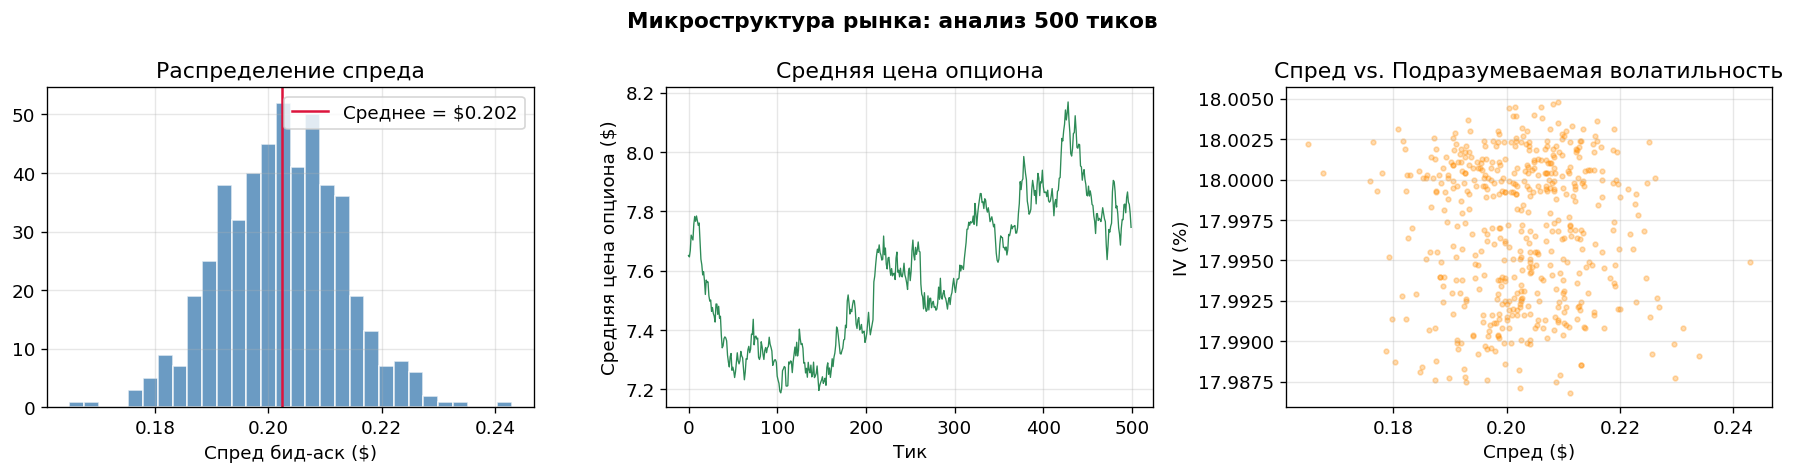

Статистика спреда — Среднее: $0.2025 | Медиана: $0.2026 | Макс.: $0.2430
Полуспред        — Среднее: $0.1012  (минимальное преимущество для торговли)


In [29]:
# ─────────────────────────────────────────────
# ЗАДАНИЕ C — Анализ распределения спреда бид-аск
# ─────────────────────────────────────────────

# Предоставлено: извлечь данные спреда из смоделированной сессии
sim_analysis = MarketSimulator(seed=42)
spread_data, mid_data, S_data, iv_data = [], [], [], []

for _ in range(min(500, sim_analysis._total_ticks)):
    t = sim_analysis.get_tick()
    if t is None:
        break
    spread_data.append(t['spread'])
    mid_data.append(t['mid'])
    S_data.append(t['S'])
    iv_data.append(t['iv'])
    sim_analysis.pass_()

spread_data = np.array(spread_data)
mid_data    = np.array(mid_data)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Микроструктура рынка: анализ 500 тиков', fontsize=13, fontweight='bold')

axes[0].hist(spread_data, bins=30, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(spread_data.mean(), color='crimson', label=f'Среднее = ${spread_data.mean():.3f}')
axes[0].set_xlabel('Спред бид-аск ($)')
axes[0].set_title('Распределение спреда')
axes[0].legend()

axes[1].plot(range(len(mid_data)), mid_data, color='seagreen', linewidth=0.8)
axes[1].set_xlabel('Тик')
axes[1].set_ylabel('Средняя цена опциона ($)')
axes[1].set_title('Средняя цена опциона')

axes[2].scatter(spread_data, np.array(iv_data)*100, alpha=0.3, s=8, color='darkorange')
axes[2].set_xlabel('Спред ($)')
axes[2].set_ylabel('IV (%)')
axes[2].set_title('Спред vs. Подразумеваемая волатильность')

plt.tight_layout()
plt.show()

print(f'Статистика спреда — Среднее: ${spread_data.mean():.4f} | Медиана: ${np.median(spread_data):.4f} | Макс.: ${spread_data.max():.4f}')
print(f'Полуспред        — Среднее: ${spread_data.mean()/2:.4f}  (минимальное преимущество для торговли)')

In [30]:
# ─────────────────────────────────────────────
# ЗАДАНИЕ C — Анализ студента: спред как погрешность измерения
# ─────────────────────────────────────────────

def compute_spread_cost_per_roundtrip(spread):
    """
    Вычислить суммарную долларовую стоимость круговой сделки
    (покупка по ask + продажа по bid) на один контракт при заданном спреде.

    Возвращает
    ----------
    cost : float (в долларах, при условии 100 акций на контракт)
    """
    # TODO: Реализация студентом
    # ПОДСКАЗКА: Круговая сделка обходится вам в ПОЛНЫЙ спред, а не в половину.
    
    return spread * 100


def minimum_required_edge(spread, sigma_vol_error=0.005):
    """
    Вычислить минимальное теоретическое преимущество, необходимое для обоснования сделки,
    с учётом как спреда бид-аск, так и ошибки оценки исторической волатильности.

    Параметры
    ---------
    spread         : float — текущий спред бид-аск
    sigma_vol_error: float — стандартная ошибка оценки исторической волатильности
                    (по умолчанию: 0,5 п.п. волатильности — типично для 30-дневного окна)

    Возвращает
    ----------
    min_edge : float — минимальное |V_теоретическое - V_mid| для торговли
    """
    # TODO: Реализация студентом
    #
    # Суммарная неопределённость состоит из ДВУХ компонентов:
    #   1. Рыночное трение: половина спреда бид-аск
    #   2. Неопределённость модели: вега × ошибка оценки волатильности
    #      (вега показывает, насколько изменяется цена на единицу изменения волатильности)
    #
    # Используйте текущие параметры (S, K, T, r, sigma, q) и функцию
    # compute_delta_central() из Задания A для вычисления веги:
    # vega ≈ (V(sigma + dv) - V(sigma - dv)) / (2 * dv)
    dv = 0.0000001
    V_up = bs_call_price(S, K, T, r, sigma + dv, q)
    V_down = bs_call_price(S, K, T, r, sigma - dv, q)
    vega = (V_up - V_down) / (2 * dv)
    min_edge = (spread / 2) * 100 + vega * sigma_vol_error
    #
    # ПОДСКАЗКА: min_edge = (spread / 2) + (vega * sigma_vol_error)
    return min_edge


# Предоставлено: протестировать с образцами спредов
test_spreads = [0.05, 0.10, 0.20, 0.35]
rows = []
for sp in test_spreads:
    rt_cost = compute_spread_cost_per_roundtrip(sp)
    min_edge = minimum_required_edge(sp)
    rows.append([f'${sp:.2f}', f'${rt_cost}' if rt_cost else 'TODO', f'{min_edge}' if min_edge else 'TODO'])

print(tabulate(rows, headers=['Спред', 'Стоимость круговой сделки', 'Мин. необх. преимущество'], tablefmt='github'))

| Спред   | Стоимость круговой сделки   |   Мин. необх. преимущество |
|---------|-----------------------------|----------------------------|
| $0.05   | $5.0                        |                    2.75505 |
| $0.10   | $10.0                       |                    5.25505 |
| $0.20   | $20.0                       |                   10.2551  |
| $0.35   | $35.0                       |                   17.7551  |


---
## 📋 Задание D — Песочница стратегий: волатильный арбитраж

### Теоретический контекст

**Волатильный арбитраж** использует разницу между:
- $\sigma_{impl}$ — подразумеваемой волатильностью, заложенной в рыночной цене опциона
- $\sigma_{hist}$ — реализованной исторической волатильностью базового актива

Если $\sigma_{impl} \neq \sigma_{hist}$, рынок теоретически неправильно оценивает опцион. Стратегия:

1. Оценить опцион по $\sigma_{hist}$ → получить $V_{теоретическое}$
2. Сравнить с рыночной средней ценой $V_{рыночная}$
3. Если преимущество $= |V_{теоретическое} - V_{рыночная}| > $ минимально необходимого → торговать
4. Иначе → пропустить

**Важные оговорки:**
- Историческая волатильность вычисляется в **скользящем окне** (например, 20 тиков × 5 с = 100 секунд)
- $\sigma_{hist}$ аннуализируется: $\sigma_{hist} = \text{std}(\log\text{-доходности}) \times \sqrt{\frac{252 \times 6{,}5 \times 3600}{5}}$
- Стратегия предполагает **отсутствие транзакционных издержек помимо спреда** (нет биржевых сборов, нет рыночного воздействия)

**Вопрос для обсуждения:** Если рынок **эффективен** в полусильной форме, что это означает для устойчивости обнаруженного вами преимущества? Как дискретизация вашего наблюдательного окна в 5 секунд влияет на способность обнаружить это преимущество?

In [33]:
# ─────────────────────────────────────────────
# ЗАДАНИЕ D — Стратегия волатильного арбитража
# ─────────────────────────────────────────────

class VolatilityArbitrageStrategy:
    """
    Каркас стратегии волатильного арбитража для опционов.
    Студенты реализуют ядро сигнальной и решающей логики.
    """

    def __init__(self, simulator, hist_vol_window=20, edge_multiplier=1.5,
                 max_position=5, max_ticks=500):
        """
        Параметры
        ---------
        simulator       : экземпляр MarketSimulator
        hist_vol_window : int   — скользящее окно для исторической волатильности (в тиках)
        edge_multiplier : float — требовать преимущество > множитель × мин_необх_преимущество
        max_position    : int   — максимальное количество контрактов одновременно
        max_ticks       : int   — количество тиков для выполнения стратегии
        """
        self.sim            = simulator
        self.vol_window     = hist_vol_window
        self.edge_mult      = edge_multiplier
        self.max_position   = max_position
        self.max_ticks      = max_ticks
        self._S_history     = []
        self._pnl_history   = []
        self._signal_history = []

    def compute_historical_vol(self, S_history):
        """
        Вычислить аннуализированную историческую волатильность из списка цен.

        Параметры
        ---------
        S_history : list of float — недавние цены базового актива (5-секундные интервалы)

        Возвращает
        ----------
        sigma_hist : float — аннуализированная волатильность
        """
        # TODO: Реализация студентом
        # Шаг 1: Вычислить лог-доходности: r_t = log(S_t / S_{t-1})
        # Шаг 2: Вычислить стандартное отклонение лог-доходностей
        # Шаг 3: Аннуализировать: умножить на sqrt(252 * 6.5 * 3600 / 5)
        #         (преобразует 5-секундное СО в годовое)
        # Вернуть None при недостаточном объёме данных
        
        r_t = np.log(np.array(S_history[1:]) / np.array(S_history[:-1]))
        s = np.std(r_t)
        ann = np.sqrt(252 * 6.5 * 3600 / 5)
        return s * ann

    def compute_theoretical_price(self, tick, sigma_hist):
        """
        Вычислить теоретическую цену опциона по исторической волатильности.

        Параметры
        ---------
        tick        : dict — текущий рыночный тик
        sigma_hist  : float — аннуализированная историческая волатильность

        Возвращает
        ----------
        V_theoretical : float
        """
        # TODO: Реализация студентом
        # Использовать bs_call_price() с sigma=sigma_hist и S, T_remaining из тика
        # Использовать глобальные параметры K, r, q
        return bs_call_price(tick["S"], K, tick["T_remaining"], r, sigma_hist, q)

    def generate_signal(self, tick, sigma_hist):
        """
        Сгенерировать торговый сигнал для данного тика.

        Возвращает
        ----------
        signal : str — одно из 'BUY', 'SELL', 'PASS'
        edge   : float — вычисленное преимущество (V_теоретическое - V_mid)
        """
        # TODO: Реализация студентом
        #
        # Шаг 1: Вычислить теоретическую цену через compute_theoretical_price()
        # Шаг 2: Вычислить преимущество = V_теоретическое - tick['mid']
        # Шаг 3: Вычислить порог = edge_multiplier × minimum_required_edge(tick['spread'])
        #
        # Логика принятия решений:
        #   если преимущество >  порог  и позиция < max_position  → 'BUY'
        #   если преимущество < -порог  и позиция > 0             → 'SELL'
        #   иначе                                                  → 'PASS'
        #
        # ВАЖНО: также проверить, что текущая позиция симулятора соответствует max_position
        
        V_th = self.compute_theoretical_price(tick, sigma_hist)
        edge = V_th - tick['mid']
        p = self.edge_mult * minimum_required_edge(tick['spread'])
        
        pos = self.sim.get_pnl()['position']
        if edge > p and pos < self.max_position:
            return 'BUY', edge
        elif edge < -p and pos > 0:
            return 'SELL', edge
        else:
            return 'PASS', edge

    def run(self):
        """Выполнить стратегию на протяжении max_ticks. Предоставленный цикл — не изменять."""
        print(f'▶  Запуск стратегии VolArb на {self.max_ticks} тиках...')
        for tick_n in range(self.max_ticks):
            tick = self.sim.get_tick()
            if tick is None:
                print(f'   Сессия завершилась на тике {tick_n}.')
                break

            self._S_history.append(tick['S'])

            if len(self._S_history) < self.vol_window + 1:
                self.sim.pass_()
                self._pnl_history.append(self.sim.get_pnl()['total'])
                self._signal_history.append('WARMUP')
                continue

            sigma_hist = self.compute_historical_vol(self._S_history[-self.vol_window-1:])
            if sigma_hist is None:
                self.sim.pass_()
                self._pnl_history.append(self.sim.get_pnl()['total'])
                self._signal_history.append('PASS')
                continue

            signal, edge = self.generate_signal(tick, sigma_hist)
            self._signal_history.append(signal)

            if signal == 'BUY':
                result = self.sim.buy(1)
            elif signal == 'SELL':
                result = self.sim.sell(1)
            else:
                result = self.sim.pass_()

            self._pnl_history.append(self.sim.get_pnl()['total'])

        final_pnl = self.sim.get_pnl()
        print(f'\n📊 Результаты стратегии:')
        print(f'   Итоговый P&L      : ${final_pnl["total"]:,.2f}')
        print(f'   Итоговая позиция  : {final_pnl["position"]} контрактов')
        print(f'   Прошло тиков      : {final_pnl["ticks_elapsed"]}')
        signals_arr = np.array(self._signal_history)
        print(f'   Покупки           : {(signals_arr == "BUY").sum()}')
        print(f'   Продажи           : {(signals_arr == "SELL").sum()}')
        print(f'   Пропуски          : {(signals_arr == "PASS").sum()}')
        return self._pnl_history


# ── Запуск стратегии ──────────────────────────────────────────────────────
sim_strategy = MarketSimulator(seed=2024)
strategy     = VolatilityArbitrageStrategy(sim_strategy, hist_vol_window=20,
                                            edge_multiplier=1.5, max_position=5,
                                            max_ticks=500)
pnl_history  = strategy.run()

▶  Запуск стратегии VolArb на 500 тиках...

📊 Результаты стратегии:
   Итоговый P&L      : $0.00
   Итоговая позиция  : 0 контрактов
   Прошло тиков      : 500
   Покупки           : 0
   Продажи           : 0
   Пропуски          : 480


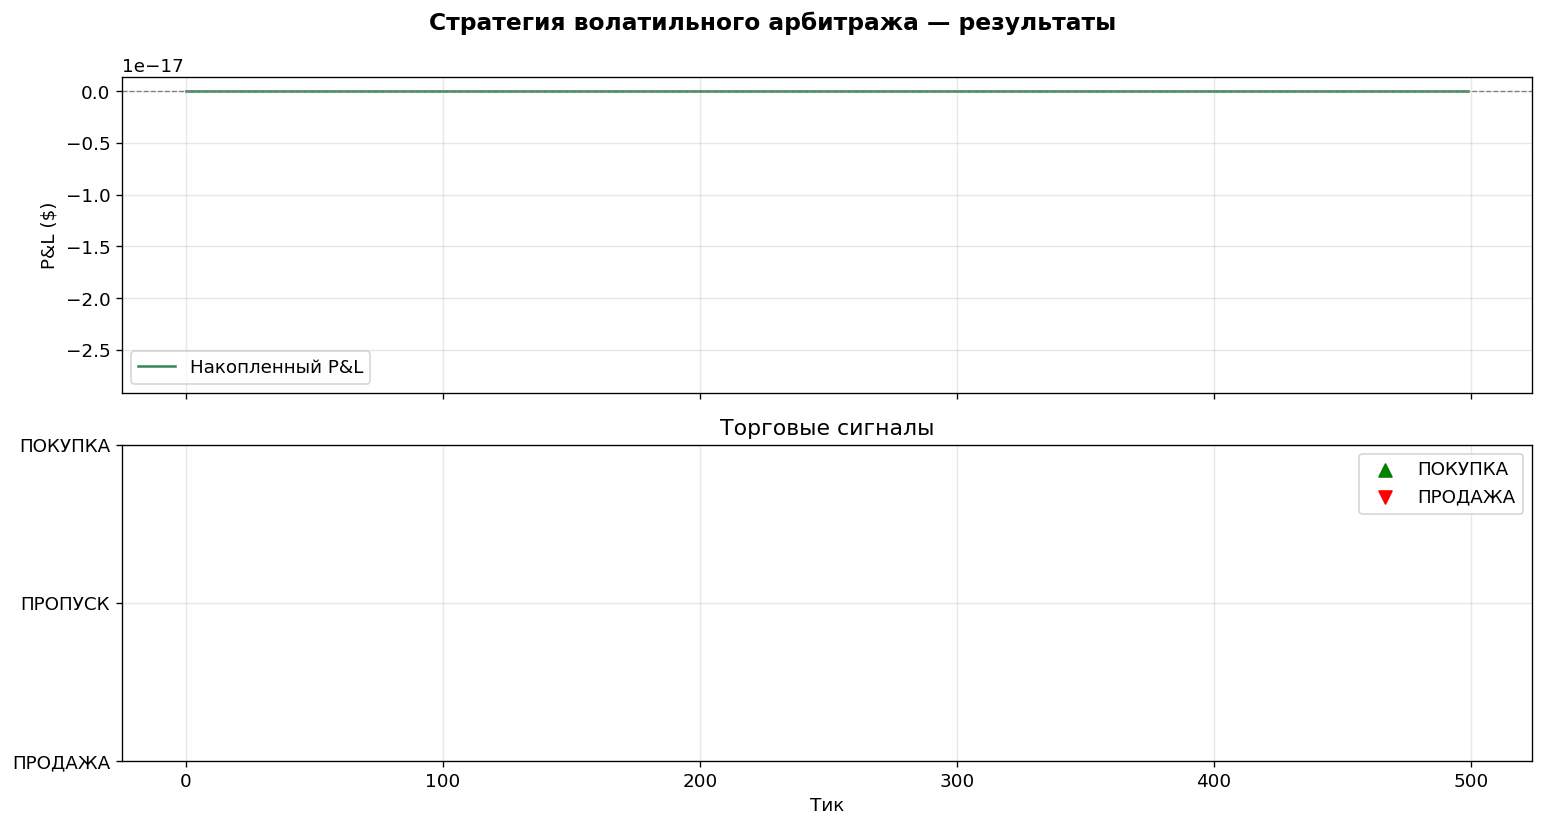

In [32]:
# ─────────────────────────────────────────────
# ЗАДАНИЕ D — Визуализация P&L стратегии  (Предоставлено)
# ─────────────────────────────────────────────

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
fig.suptitle('Стратегия волатильного арбитража — результаты', fontsize=14, fontweight='bold')

axes[0].plot(pnl_history, color='seagreen', linewidth=1.5, label='Накопленный P&L')
axes[0].axhline(0, color='gray', linewidth=0.8, linestyle='--')
axes[0].fill_between(range(len(pnl_history)), pnl_history, 0,
                     where=[p >= 0 for p in pnl_history], alpha=0.15, color='green')
axes[0].fill_between(range(len(pnl_history)), pnl_history, 0,
                     where=[p < 0 for p in pnl_history], alpha=0.15, color='red')
axes[0].set_ylabel('P&L ($)')
axes[0].legend()

signals = strategy._signal_history
buy_idx  = [i for i, s in enumerate(signals) if s == 'BUY']
sell_idx = [i for i, s in enumerate(signals) if s == 'SELL']

axes[1].scatter(buy_idx,  [1]*len(buy_idx),  marker='^', color='green', s=60, label='ПОКУПКА', zorder=5)
axes[1].scatter(sell_idx, [-1]*len(sell_idx), marker='v', color='red',   s=60, label='ПРОДАЖА', zorder=5)
axes[1].set_yticks([-1, 0, 1])
axes[1].set_yticklabels(['ПРОДАЖА', 'ПРОПУСК', 'ПОКУПКА'])
axes[1].set_xlabel('Тик')
axes[1].set_title('Торговые сигналы')
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.show()

---
## 📋 Задание E — Ошибка дискретизации: потери от 5-секундного запаздывания

### Теоретический контекст

**Дельта-хеджирование** в теории Блэка–Шоулза предполагает **непрерывную ребалансировку**. На практике мы ребалансируем каждые $\Delta t = 5$ секунд. Это вносит **ошибку дискретизации** — P&L хеджа отстаёт от истинного непрерывного P&L.

**Потери от запаздывания** за один интервал ребалансировки приближённо равны:

$$\text{ПотериОтЗапаздывания}(\Delta t) \approx \frac{1}{2} \Gamma \cdot (\delta S)^2$$

где $\delta S = S_{t+\Delta t} - S_t$ — изменение цены за один интервал.

Интегрируя по торговой сессии, **ожидаемые суммарные потери от дискретизации** равны:

$$\mathbb{E}[\text{Суммарные потери}] \approx \frac{1}{2} \Gamma \cdot \sigma^2 S^2 \cdot T_{сессия}$$

где $T_{сессия}$ — продолжительность сессии в годах.

**Вопросы для обсуждения:**
1. Почему гамма является ключевым параметром в формуле потерь? (Подумайте о геометрическом смысле гаммы.)
2. Если удвоить частоту ребалансировки (2,5 секунды), приблизительно во сколько раз изменятся ожидаемые потери? Приведите вывод.
3. Всегда ли потери от запаздывания являются *издержками*? Опишите сценарий, в котором дискретизация может быть выгодна.

In [ ]:
# ─────────────────────────────────────────────
# ЗАДАНИЕ E — Калькулятор потерь от дискретизации
# ─────────────────────────────────────────────

def compute_lag_loss_per_tick(S_current, S_next, gamma):
    """
    Вычислить потери P&L из-за дискретной ребалансировки за один тик.

    Параметры
    ---------
    S_current : float — цена базового актива в тике t
    S_next    : float — цена базового актива в тике t+1
    gamma     : float — гамма опциона в тике t

    Возвращает
    ----------
    lag_loss : float — в единицах цены опциона (ещё не умноженных на 100 акций)
    """
    # TODO: Реализация студентом
    # Применить формулу: ПотериОтЗапаздывания = 0.5 × Гамма × (δS)²
    pass


def compute_total_lag_loss(sim_instance, h_sweet=1e-4):
    """
    Пройти всю сессию симулятора и накопить потери от запаздывания.
    Использует оптимальное h из Задания A для вычисления гаммы.

    Возвращает
    ----------
    lag_losses     : список потерь за каждый тик
    cumulative     : список накопленных потерь
    theoretical_est: float — аналитическая оценка по формуле выше
    """
    # TODO: Реализация студентом
    #
    # СТРУКТУРА:
    # lag_losses = []
    # prev_S = None
    # для каждого тика:
    #   1. Получить данные тика
    #   2. Вычислить гамму через compute_gamma_central() с S и T_remaining тика
    #   3. Если prev_S не None:
    #        loss = compute_lag_loss_per_tick(prev_S, tick['S'], gamma)
    #        lag_losses.append(loss)
    #   4. prev_S = tick['S']
    #   5. sim.pass_()
    #
    # Также вычислить теоретическую оценку:
    #   T_session = 6.5 / (252 * 24)  # 6.5 часа в годах
    #   theoretical = 0.5 * gamma_analytical * sigma**2 * S**2 * T_session
    pass


# Предоставлено: запустить и визуализировать
sim_lag = MarketSimulator(seed=99)

result = compute_total_lag_loss(sim_lag, h_sweet=1e-4)

if result is not None:
    lag_losses, cumulative, theoretical_est = result

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    fig.suptitle('Потери от дискретизации: ребалансировка каждые 5 секунд', fontsize=13, fontweight='bold')

    axes[0].hist([l for l in lag_losses if l is not None], bins=50,
                 color='darkorange', edgecolor='white', alpha=0.8)
    axes[0].set_xlabel('Потери за тик ($)')
    axes[0].set_title('Распределение потерь от запаздывания')

    axes[1].plot(cumulative, color='royalblue', linewidth=1.5)
    axes[1].axhline(theoretical_est, color='crimson', linestyle='--',
                    label=f'Теоретич.: ${theoretical_est:.4f}')
    axes[1].set_xlabel('Тик')
    axes[1].set_ylabel('Накопленные потери ($)')
    axes[1].set_title('Накопленные потери vs. теоретические')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    print(f'\nСуммарные смоделированные потери : ${sum(l for l in lag_losses if l is not None):.4f}')
    print(f'Теоретическая оценка             : ${theoretical_est:.4f}')
    print(f'Отношение (модель/теория)         : {sum(l for l in lag_losses if l is not None)/theoretical_est:.3f}')

In [ ]:
# ─────────────────────────────────────────────
# ЗАДАНИЕ E — Чувствительность потерь к частоте ребалансировки
# ─────────────────────────────────────────────

# TODO: Реализация студентом
#
# Сравните ТЕОРЕТИЧЕСКИЕ ожидаемые потери от дискретизации для разных интервалов ребалансировки:
# delta_t = [1, 5, 30, 60, 300] секунд
#
# Для каждого delta_t:
#   Дисперсия δS масштабируется как: Var(δS) = sigma^2 * S^2 * delta_t / (252 * 6.5 * 3600)
#   Число тиков в сессии: n_ticks = 6.5 * 3600 / delta_t
#   Суммарные потери ≈ 0.5 * gamma_analytical * sigma^2 * S^2 * T_session
#   ЗАМЕЧАНИЕ: Суммарные потери НЕ зависят от delta_t! Исследуйте, почему.
#
# График: потери за тик в зависимости от delta_t
# Запишите выводы в ячейке Markdown ниже.

rebalance_intervals = [1, 5, 30, 60, 300]  # секунды

# [ВАШ КОД ЗДЕСЬ]

### ✏️ Задание E — Обсуждение (двойной щелчок для редактирования)

**Почему суммарные потери не зависят от частоты ребалансировки?**  
*[ВАШЕ МАТЕМАТИЧЕСКОЕ ОБЪЯСНЕНИЕ — приведите формулу и объясните взаимную отмену]*

**Что это означает для стратегии:**  
*[Практический вывод для выбора интервала ребалансировки]*

**Когда более частая ребалансировка ВСЁ ЖЕ помогла бы?**  
*[Подсказка: подумайте о путезависимых выплатах или транзакционных издержках]*

---
## 📋 Задание F — Синтез: бюджет ошибок для всей стратегии

### Теоретический контекст

Каждая количественная торговая стратегия имеет **бюджет ошибок** — декомпозицию всех источников неопределённости P&L. Для нашей стратегии волатильного арбитража источники ошибок:

| Источник ошибки | Тип | Из |
|---|---|---|
| Ошибка усечения конечных разностей в греках | Численная | Задание A |
| Задержка библиотеки (пропущенные тики) | Вычислительная | Задание B |
| Стоимость трения бид-аска | Микроструктура рынка | Задание C |
| Ошибка оценки исторической волатильности | Статистическая | Задание D |
| Потери от дискретизации | Математическая | Задание E |

**Условие безубыточности:** стратегия жизнеспособна только при:
$$\text{Ожидаемое преимущество} > \sum_{i} \text{Ошибка}_i + \text{Стоимость трения}$$

In [ ]:
# ─────────────────────────────────────────────
# ЗАДАНИЕ F — Отчёт по бюджету ошибок
# ─────────────────────────────────────────────

# TODO: Реализация студентом
#
# Заполните словарь error_budget результатами заданий A–E.
# Все значения выражайте в долларах НА КОНТРАКТ НА СДЕЛКУ.
#
# error_budget = {
#     'Усечение конечных разностей (ошибка Delta × dS)': ?,   # Задание A: delta_error_at_sweet × typical_dS × 100
#     'Трение бид-аска (полуспред)':                    ?,   # Задание C: средний полуспред × 100
#     'Ошибка оценки волатильности (vega × sigma_err)': ?,   # Задание C: результат minimum_required_edge
#     'Потери от дискретизации (на сделку)':            ?,   # Задание E: total_lag_loss / n_trades_expected
# }
#
# Затем вычислить:
#   total_error = sum(error_budget.values())
#   strategy_edge = ???  (из ваших наблюдений в Задании D)
#   вывести, является ли стратегия жизнеспособной

print('[TODO: Реализовать отчёт по бюджету ошибок]')

# Предоставлен каркас визуализации (отрисуется автоматически при заполнении error_budget)
# error_items = list(error_budget.keys())
# error_vals  = list(error_budget.values())
#
# fig, ax = plt.subplots(figsize=(10, 4))
# bars = ax.barh(error_items, error_vals, color='steelblue', edgecolor='white')
# ax.axvline(strategy_edge, color='crimson', linestyle='--', linewidth=2,
#            label=f'Преимущество стратегии = ${strategy_edge:.4f}')
# ax.set_xlabel('Стоимость ошибки ($ на контракт на сделку)')
# ax.set_title('Декомпозиция бюджета ошибок')
# ax.legend()
# for bar, val in zip(bars, error_vals):
#     ax.text(val + 0.0001, bar.get_y() + bar.get_height()/2, f'${val:.5f}', va='center', fontsize=9)
# plt.tight_layout()
# plt.show()

### ✏️ Задание F — Итоговый анализ (двойной щелчок для редактирования)

**Является ли стратегия жизнеспособной согласно вашему бюджету ошибок?**  
*[ДА/НЕТ и количественное обоснование]*

**Какой единственный источник ошибок оказывает наибольшее влияние?**  
*[ВАШ ОТВЕТ — объясните математику, почему он доминирует]*

**Если бы вы могли исправить только один источник ошибок, какой бы вы выбрали и как?**  
*[Ваше инженерное предложение — будьте конкретны относительно математического изменения]*

**Как изменился бы ваш анализ для американского опциона по сравнению с европейским?**  
*[Обсудите: аналитические vs. численные греки, какая библиотека предпочтительнее и почему]*

---

## ✅ Чек-лист 80-минутной лабораторной работы

Используйте этот чек-лист для отслеживания прогресса во время сессии.

---

### 🕐 Минуты 0–15 | Настройка и Задание A (Конечные разности)

- [ ] Успешно запустить все предоставленные установочные ячейки (пакеты, импорты, параметры)
- [ ] **[A1]** Реализовать `compute_delta_central(S, K, T, r, sigma, q, h)`
- [ ] **[A2]** Реализовать `compute_gamma_central(S, K, T, r, sigma, q, h)`
- [ ] **[A3]** Запустить перебор шагов и построить лог-лог график ошибок
- [ ] **[A4]** Определить оптимальное $h^*$ для дельты по графику
- [ ] **[A5]** Заполнить таблицу сравнения трёх режимов (слишком малый / оптимум / слишком большой)
- [ ] **[A6]** Ответить на 3 вопроса для обсуждения в ячейке Markdown

---

### 🕐 Минуты 15–30 | Задание B (Бенчмаркинг библиотек)

- [ ] **[B1]** Запустить установочную ячейку QuantLib — убедиться, что `ql_option.delta()` совпадает с аналитическим
- [ ] **[B2]** Использовать `%timeit` для замера `build_quantlib_option(...).delta()`
- [ ] **[B3]** Использовать `%timeit` для замера `bs_delta_analytical(...)`
- [ ] **[B4]** Реализовать ячейку сравнения времени для портфеля из 50 опционов
- [ ] **[B5]** Заполнить ячейку Markdown с рекомендацией и обоснованием

---

### 🕐 Минуты 30–45 | Задание C (Трение бид-аска)

- [ ] **[C1]** Реализовать `compute_spread_cost_per_roundtrip(spread)`
- [ ] **[C2]** Реализовать `minimum_required_edge(spread, sigma_vol_error)`
      - Должна включать вклад веги из центральной разности
- [ ] **[C3]** Убедиться, что график анализа спреда отображается (микроструктура 500 тиков)
- [ ] **[C4]** Заполнить таблицу стоимости спреда для 4 тестовых значений
- [ ] **[C5]** Ответить на 3 вопроса для обсуждения в ячейке Markdown

---

### 🕐 Минуты 45–60 | Задание D (Стратегия VolArb)

- [ ] **[D1]** Реализовать `compute_historical_vol(S_history)`
      - Должна корректно аннуализировать из 5-секундных доходностей
- [ ] **[D2]** Реализовать `compute_theoretical_price(tick, sigma_hist)`
- [ ] **[D3]** Реализовать `generate_signal(tick, sigma_hist)` — ядро логики КУПИТЬ/ПРОДАТЬ/ПРОПУСТИТЬ
      - Должна использовать `minimum_required_edge()` в качестве порога
      - Должна соблюдать ограничение `max_position`
- [ ] **[D4]** Запустить стратегию на 500 тиках — увидеть график P&L и диаграмму сигналов
- [ ] **[D5]** Ответить на вопрос об эффективности рынка

---

### 🕐 Минуты 60–75 | Задание E (Потери от дискретизации)

- [ ] **[E1]** Реализовать `compute_lag_loss_per_tick(S_current, S_next, gamma)`
- [ ] **[E2]** Реализовать `compute_total_lag_loss(sim_instance, h_sweet)` — полная сессия
- [ ] **[E3]** Запустить и сравнить смоделированные и теоретические потери от запаздывания
- [ ] **[E4]** Реализовать анализ чувствительности к частоте ребалансировки
- [ ] **[E5]** Объяснить независимость от частоты в ячейке Markdown

---

### 🕐 Минуты 75–80 | Задание F (Бюджет ошибок) + Завершение

- [ ] **[F1]** Заполнить словарь `error_budget` результатами заданий A–E
- [ ] **[F2]** Отобразить столбчатый график бюджета ошибок
- [ ] **[F3]** Определить, превышает ли преимущество стратегии суммарный бюджет ошибок
- [ ] **[F4]** Заполнить все 4 вопроса для обсуждения в финальной ячейке Markdown
- [ ] **[СДАТЬ]** Сохранить ноутбук как `[ВашеИмя]_PrecisionProfit_Lab.ipynb`

---

### 🏆 Дополнительные задания (при наличии времени)

- [ ] **[ДОП-1]** Повторить Задание A с формулой прямых разностей — сравнить кривые ошибок с центральными разностями. Эмпирически подтвердить сходимость $O(h)$ vs $O(h^2)$.
- [ ] **[ДОП-2]** Реализовать **дельта-нейтральную** версию стратегии VolArb, где вы хеджируете позицию по опциону позицией в базовом активе. Как это изменяет профиль P&L?
- [ ] **[ДОП-3]** Исследовать влияние `edge_multiplier` в Задании D. Построить P&L как функцию множителя (диапазон: 0,5–3,0). Какое значение оптимально и почему?
- [ ] **[ДОП-4]** Вывести аналитически (на бумаге, затем проверить численно) значение $h$, минимизирующее суммарную ошибку для формулы центральных разностей гаммы. Сравнить с оптимумом дельты.